<a href="https://colab.research.google.com/github/VanishingPizza/Machine-Learning/blob/main/HW2/data_prop_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load dataset into a Pandas DataFrame


In [2]:
import pandas as pd
df=pd.read_csv('cybersecurity_intrusion_data.csv')


Use Structural Inspection Methods to analyze features


In [3]:
df.head()
print("\n --- Dataframe Info--- ")
df.info()
print("\n --- Summary Statistics---")
df.describe()


 --- Dataframe Info--- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB

 --- Summary Statistics---


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [4]:
print("\n --- Missing Values Count --- ")
print(df.isnull().sum())




 --- Missing Values Count --- 
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


In [5]:
df["protocol_type"].value_counts()

,count
protocol_type,
TCP,6624
UDP,2406
ICMP,507


In [5]:
df["encryption_used"].value_counts()

,count
encryption_used,
AES,4706
DES,2865


In [6]:
df["browser_type"].value_counts()

,count
browser_type,
Chrome,5137
Firefox,1944
Edge,1469
Unknown,502
Safari,485


In [6]:
df_cleaned=df.drop("session_id",axis=1)
df_cleaned.info()
df_cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  9537 non-null   int64  
 1   protocol_type        9537 non-null   object 
 2   login_attempts       9537 non-null   int64  
 3   session_duration     9537 non-null   float64
 4   encryption_used      7571 non-null   object 
 5   ip_reputation_score  9537 non-null   float64
 6   failed_logins        9537 non-null   int64  
 7   browser_type         9537 non-null   object 
 8   unusual_time_access  9537 non-null   int64  
 9   attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 745.2+ KB


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


Quantify missing values across the columns and implement imputation strategy using Scikit-Learn's SimpleImputer to handle missing entries

In [7]:
df_cleaned.dropna(subset=["encryption_used"])


,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...
9528,535,TCP,7,50.518476,DES,0.767659,1,Edge,1,1
9531,746,TCP,7,315.151758,DES,0.190059,3,Chrome,0,1
9532,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9534,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0


In [13]:
df_num=df_cleaned.drop(["encryption_used","protocol_type","browser_type"],axis=1)
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  9537 non-null   int64  
 1   login_attempts       9537 non-null   int64  
 2   session_duration     9537 non-null   float64
 3   ip_reputation_score  9537 non-null   float64
 4   failed_logins        9537 non-null   int64  
 5   unusual_time_access  9537 non-null   int64  
 6   attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 521.7 KB


In [14]:
imputer.fit(df_num)
X=imputer.transform(df_num)
df_tr=pd.DataFrame(X,columns=df_num.columns, index=df_num.index)

Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (e.g., StandardScaler) to numerical columns and encoding (e.g., OneHotEncoder) to categorical columns.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [16]:
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        #('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

In [17]:
df_num_tr = num_pipeline.fit_transform(df_num)

In [18]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

In [19]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [20]:
from sklearn.compose import ColumnTransformer
nums_attribs = list(df_num)
cat_attribs = ["protocol_type","encryption_used","browser_type"]
full_pipeline= ColumnTransformer([
      ('num', num_pipeline, nums_attribs),
      ('cat', OneHotEncoder(), cat_attribs)])
df_prepared = full_pipeline.fit_transform(df)

Compute the Pearson correlation matrix for the numerical features, generate a Seaborn heatmap with annotations, and create at least two distribution plots and one scatter plot to examine feature relationships and the target variable (attack_detected).


 --- Seaborn HeatMap---


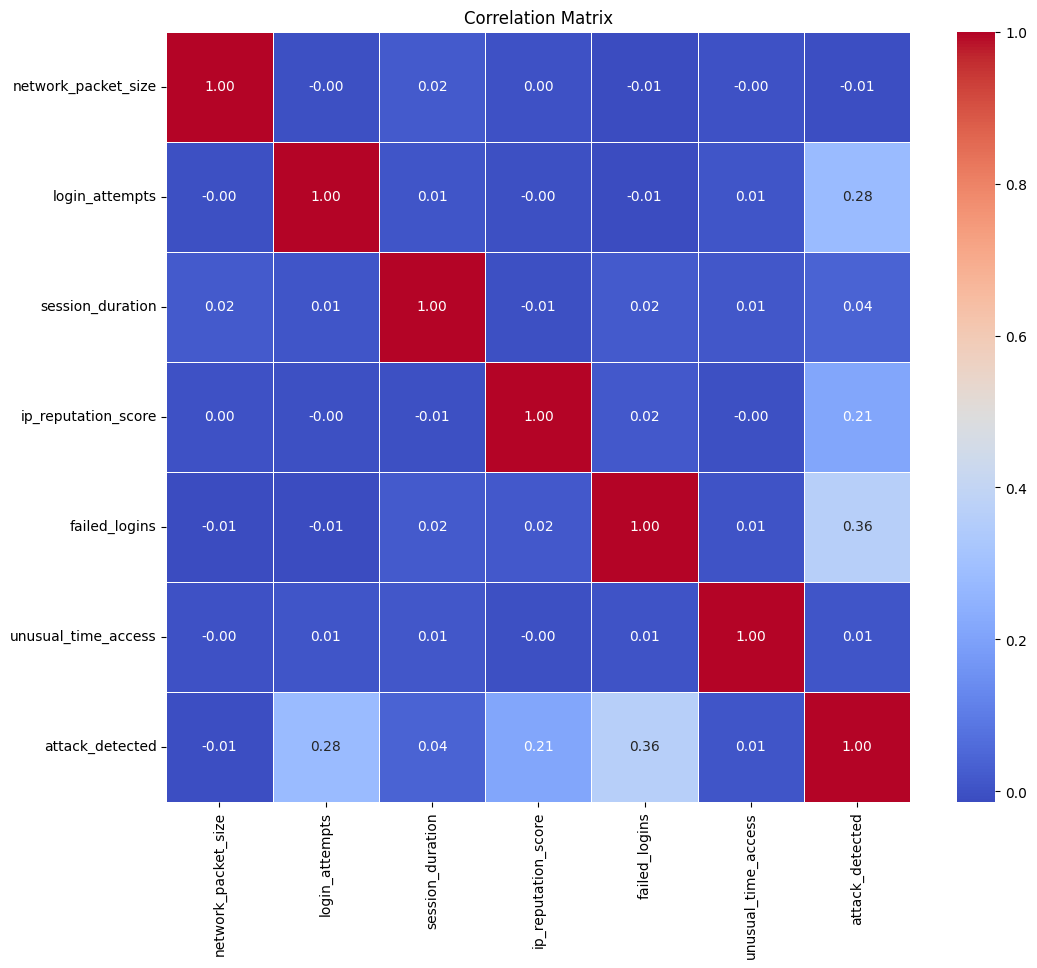

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

#Pearson correlation matrix for numerical features
corr_matrix=df.select_dtypes(include=['int64','float64']).corr()
#corr_matrix["attack_detected"].sort_values(ascending=False)
#Seaborn heatmap for correlatiion matrix
print("\n --- Seaborn HeatMap---")
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [22]:
corr_matrix["attack_detected"].sort_values(ascending=False)

,attack_detected
attack_detected,1.000000
failed_logins,0.363726
login_attempts,0.277320
ip_reputation_score,0.211540
session_duration,0.041602
unusual_time_access,0.008652
network_packet_size,-0.006798


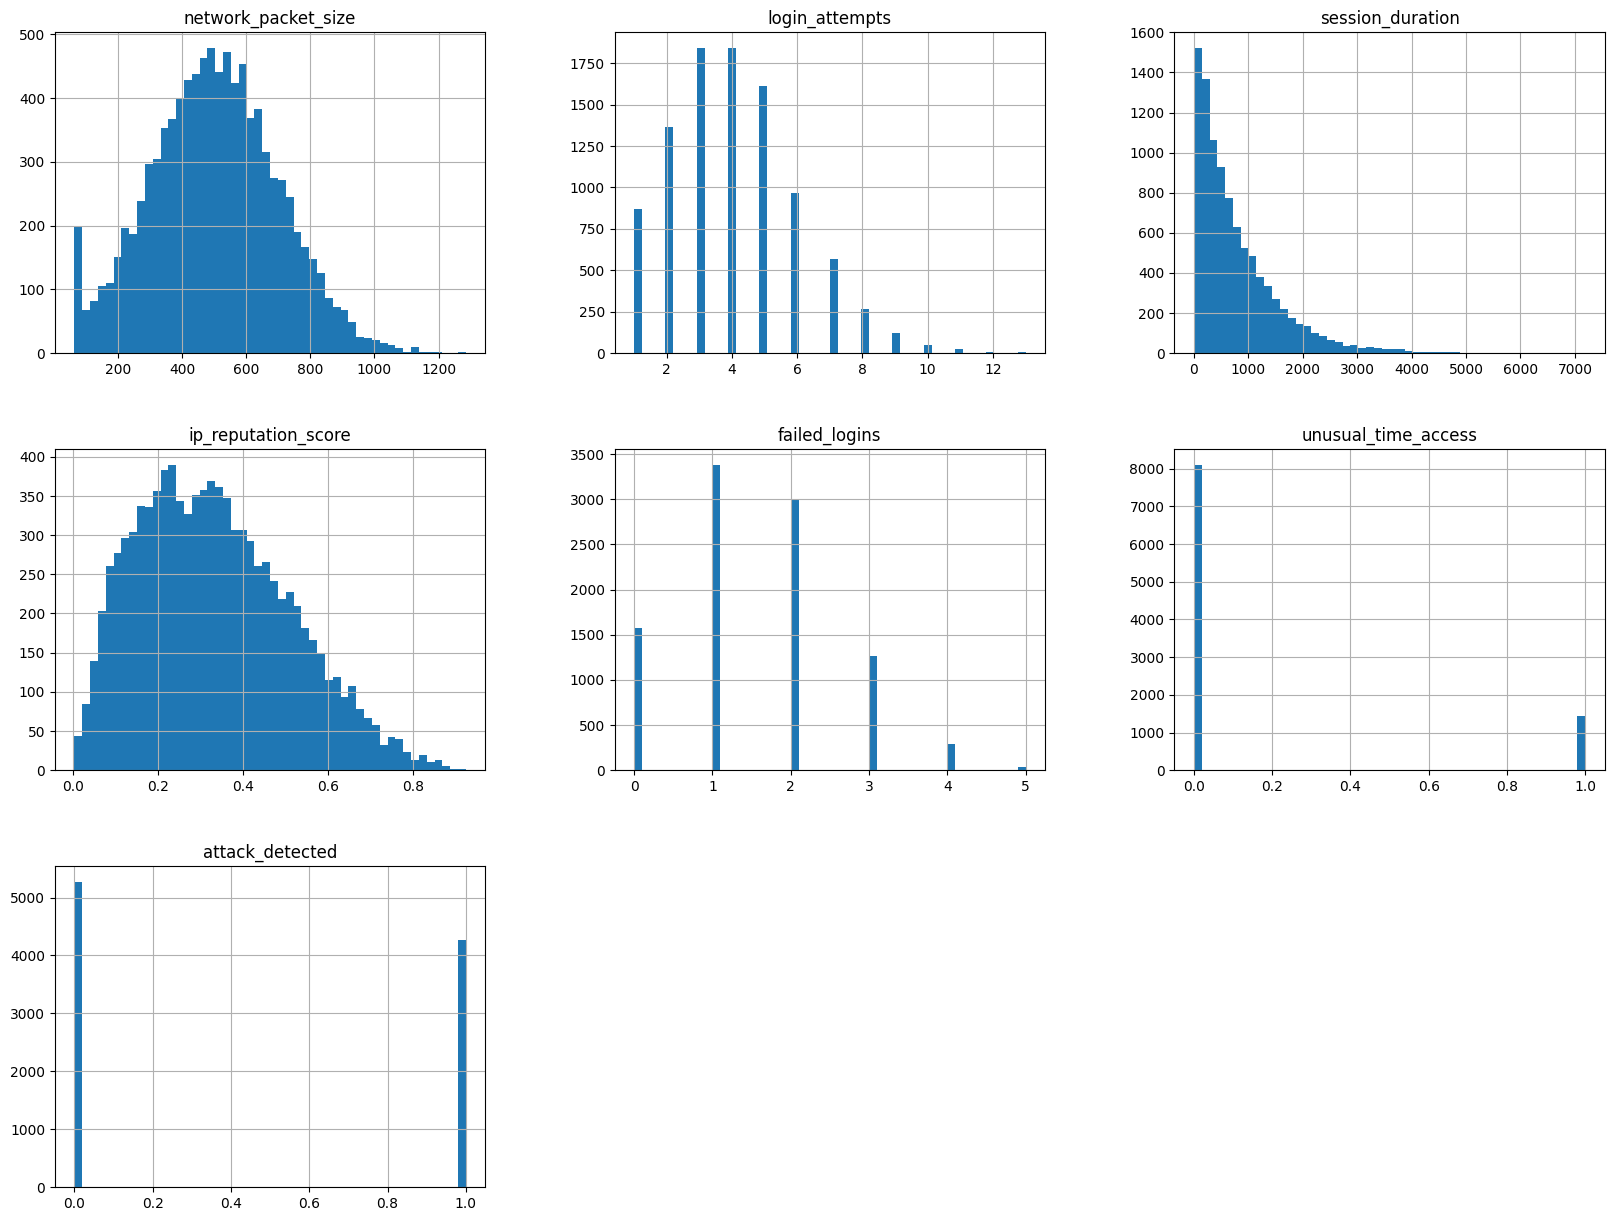

In [23]:
df_num.hist(bins=50,figsize=(20,15))
plt.show()

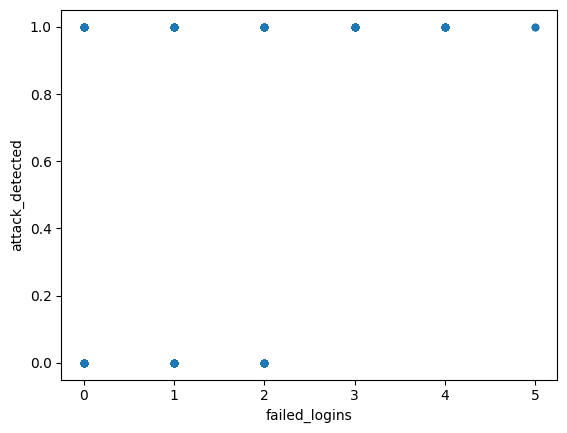

In [25]:
df_num.plot(kind="scatter",x="failed_logins",y="attack_detected",alpha=0.1)
plt.show()